In [55]:
%autosave 60

Autosaving every 60 seconds


In [56]:
import os
import time
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Итотовая работа по ML
- Подробности на странице на платформе
- Данные для этой работы - это датасет с бинарной целевой переменной. Данные доступны по ссылке на платформе.


Вот описание данных:

**Данные по оттоку клиентов**
- client_id - уникальный id клиента
- регион - локация клиента
- использование - использование мобильной связи
- сумма - сумма пополнения баланса
- частота_пополнения - сколько раз клиент пополнял аккаунт
- доход - доход с одного клиента в месяц
- сегмент_arpu - выручка за квартал
- частота - сколько раз клиент приносил прибыль
- объем_данных - число раз, когда клиент делал подключение
- on_net - число звонков внутри сети
- продукт_1 - тариф 1
- продукт_2 - тариф 2
- зона_1 - звонки из гео-области 1
- зона_2 - звонки из гео-области 2
- mrg_ - флаг
- секретный_скор - некоторый модельный скор клиента
- pack - самый активный пакет клиента
- pack_freq - частота активации пакета pack
- binary_target - флаг оттока клиента

In [57]:
path_data = './'

# не меняйте название переменных train и test - в которых лежат датасеты train.csv и test_full.csv соответсвенно
# эти файлы будут участвовать в тестировании работы

train = pd.read_csv(path_data + 'train.csv')

# test датасет запрещается видоизменять - применять к нему какую либо логику трансформации
# можно видоизменять входные данные внутри функции def get_score(dict_input) (смотри ниже)

test = pd.read_csv(path_data + 'test_full.csv')

## Место для вашего кода ↓↓↓

## Обучение модели / написание вспомогательно кода ↓↓↓

In [58]:
train.head()

,client_id,регион,использование,сумма,частота_пополнения,доход,сегмент_arpu,частота,объем_данных,on_net,продукт_1,продукт_2,зона_1,зона_2,mrg_,секретный_скор,pack,pack_freq,binary_target
0,0,Уран,>24LY,14.617797,1.0,27034.974914,71.37,1.000000,NaN,26.0,10.0,NaN,NaN,NaN,False,0.540984,_output-_сеть 500 (условие) 2000f;5d,1.000000,0
1,1,Марс,>24LY,32.686083,3.0,40373.828300,354.27,2.000000,35.679126,45.0,8.0,NaN,NaN,NaN,False,0.573770,тариф_a 250 (условие) _безлим_c_output_сутки,1.414214,0
2,2,Церера,>24LY,25.318570,3.0,32004.378374,139.74,1.414214,NaN,NaN,13.0,NaN,NaN,NaN,False,0.131148,NaN,NaN,0
3,3,Марс,>24LY,70.710678,38.0,59953.505011,1722.65,6.403124,163.309522,203.0,274.0,NaN,NaN,0.031817,False,0.885246,"трафик: 100 (условие) 40mb,_сутки",4.000000,0
4,4,Меркурий,>24LY,9.244999,2.0,21499.998428,28.63,1.414214,5.000000,NaN,NaN,NaN,NaN,NaN,False,0.344262,"трафик: 100 (условие) 40mb,_сутки",1.000000,0


In [59]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010248 entries, 0 to 1010247
Data columns (total 19 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   client_id           1010248 non-null  int64  
 1   регион              612396 non-null   object 
 2   использование       1010248 non-null  object 
 3   сумма               655354 non-null   float64
 4   частота_пополнения  655354 non-null   float64
 5   доход               669787 non-null   float64
 6   сегмент_arpu        669787 non-null   float64
 7   частота             669787 non-null   float64
 8   объем_данных        512886 non-null   float64
 9   on_net              641315 non-null   float64
 10  продукт_1           590287 non-null   float64
 11  продукт_2           405005 non-null   float64
 12  зона_1              79807 non-null    float64
 13  зона_2              64000 non-null    float64
 14  mrg_                1010248 non-null  bool   
 15  секретный_скор 

In [60]:
train.isnull().sum()


client_id                  0
регион                397852
использование              0
сумма                 354894
частота_пополнения    354894
доход                 340461
сегмент_arpu          340461
частота               340461
объем_данных          497362
on_net                368933
продукт_1             419961
продукт_2             605243
зона_1                930441
зона_2                946248
mrg_                       0
секретный_скор             0
pack                  423275
pack_freq             423275
binary_target              0
dtype: int64

In [61]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import numpy as np
import pandas as pd


numerical = ['сумма', 'частота_пополнения', 'доход', 'сегмент_arpu', 'частота',
             'объем_данных', 'on_net', 'продукт_1', 'продукт_2', 'зона_1', 'зона_2', 'секретный_скор', 'pack_freq']
categorical = ['использование', 'регион', 'pack']
boolean_features = ['mrg_']


In [62]:

for col in numerical:
    median = train[col].median()
    train[col] = train[col].fillna(median)


for col in categorical:
    train[col] = train[col].fillna('unknown')


In [63]:
train.isnull().sum()

client_id             0
регион                0
использование         0
сумма                 0
частота_пополнения    0
доход                 0
сегмент_arpu          0
частота               0
объем_данных          0
on_net                0
продукт_1             0
продукт_2             0
зона_1                0
зона_2                0
mrg_                  0
секретный_скор        0
pack                  0
pack_freq             0
binary_target         0
dtype: int64

In [64]:
train.describe()

,client_id,сумма,частота_пополнения,доход,сегмент_arpu,частота,объем_данных,on_net,продукт_1,продукт_2,зона_1,зона_2,секретный_скор,pack_freq,binary_target
count,1.010248e+06,1.010248e+06,1.010248e+06,1.010248e+06,1.010248e+06,1.010248e+06,1.010248e+06,1.010248e+06,1.010248e+06,1.010248e+06,1.010248e+06,1.010248e+06,1.010248e+06,1.010248e+06,1.010248e+06
mean,5.051235e+05,3.944685e+01,9.568419e+00,4.266349e+04,6.628748e+02,3.183317e+00,2.530888e+01,1.858427e+02,6.769371e+01,1.286139e+01,3.257512e-04,7.446951e-02,4.433381e-01,2.447176e+00,1.873649e-01
std,2.916336e+05,2.056381e+01,1.098808e+01,1.175270e+04,8.436176e+02,1.463252e+00,3.458001e+01,7.060226e+02,1.582702e+02,4.078677e+01,2.508181e-03,2.487360e-01,3.651556e-01,1.215650e+00,3.902044e-01
min,0.000000e+00,2.924038e+00,1.000000e+00,5.726010e+03,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,2.525618e+05,2.923525e+01,4.000000e+00,3.774592e+04,2.705100e+02,2.449490e+00,1.516575e+01,1.200000e+01,2.000000e+01,6.000000e+00,2.086811e-04,6.363347e-02,8.196721e-02,2.000000e+00,0.000000e+00
50%,5.051235e+05,3.580573e+01,6.000000e+00,4.231177e+04,4.273500e+02,3.000000e+00,1.600000e+01,2.700000e+01,2.900000e+01,6.000000e+00,2.086811e-04,6.363347e-02,3.770492e-01,2.236068e+00,0.000000e+00
75%,7.576852e+05,4.409580e+01,1.000000e+01,4.733500e+04,6.692300e+02,3.605551e+00,1.700000e+01,5.500000e+01,4.100000e+01,6.000000e+00,2.086811e-04,6.363347e-02,8.196721e-01,2.449490e+00,0.000000e+00
max,1.010247e+06,3.365232e+02,1.330000e+02,1.298440e+05,3.789872e+04,9.539392e+00,1.304726e+03,5.080900e+04,1.204000e+04,4.174000e+03,1.000000e+00,1.000000e+02,1.000000e+00,2.507987e+01,1.000000e+00


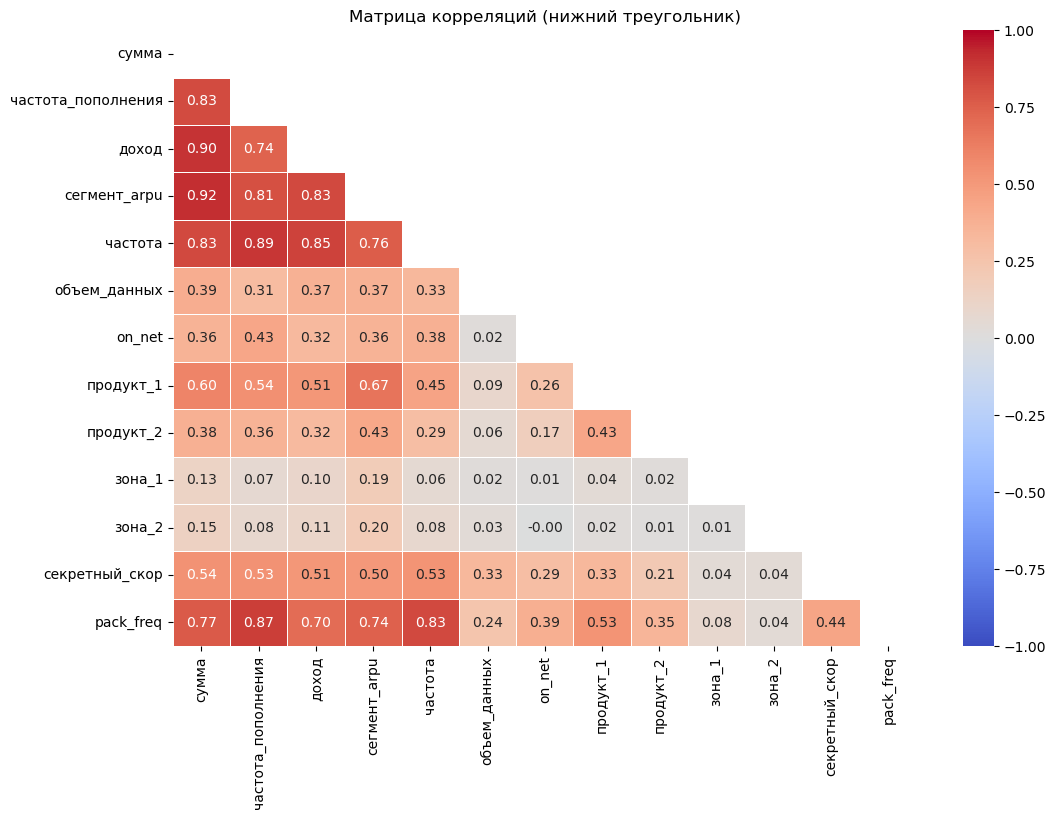

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = train[numerical].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,          # Применяем маску
    annot=True,          # Показываем значения
    cmap='coolwarm',     # Цветовая схема
    fmt=".2f",           # Формат чисел
    linewidths=0.5,      # Разделительные линии
    vmin=-1, vmax=1      # Фиксируем диапазон для цвета
)
plt.title("Матрица корреляций (нижний треугольник)")
plt.show()


In [66]:
train = train.drop(columns=['сумма', 'частота_пополнения', 'частота', 'pack_freq'])

In [67]:
numerical = [  'доход', 'сегмент_arpu',
             'объем_данных', 'on_net', 'продукт_1', 'продукт_2', 'зона_1', 'зона_2', 'секретный_скор']

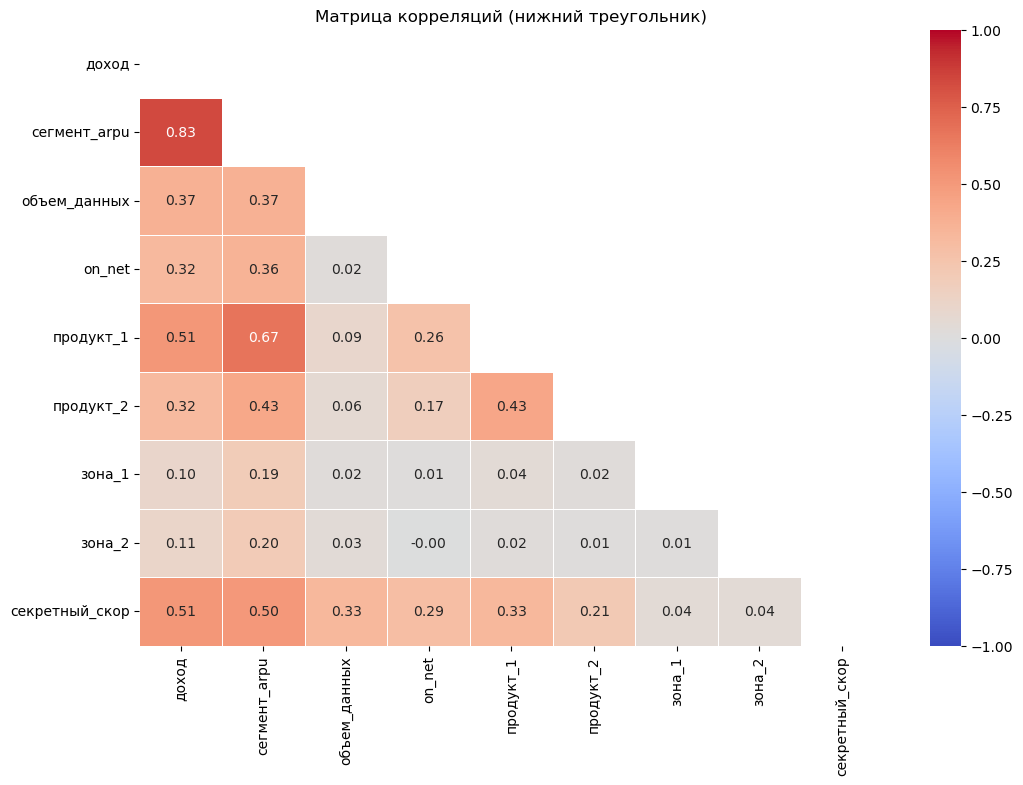

In [68]:
corr_matrix = train[numerical].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,          
    annot=True,         
    cmap='coolwarm',     
    fmt=".2f",           
    linewidths=0.5,      
    vmin=-1, vmax=1      
)
plt.title("Матрица корреляций (нижний треугольник)")
plt.show()

In [69]:
train

,client_id,регион,использование,доход,сегмент_arpu,объем_данных,on_net,продукт_1,продукт_2,зона_1,зона_2,mrg_,секретный_скор,pack,binary_target
0,0,Уран,>24LY,27034.974914,71.37,16.000000,26.0,10.0,6.0,0.000209,0.063633,False,0.540984,_output-_сеть 500 (условие) 2000f;5d,0
1,1,Марс,>24LY,40373.828300,354.27,35.679126,45.0,8.0,6.0,0.000209,0.063633,False,0.573770,тариф_a 250 (условие) _безлим_c_output_сутки,0
2,2,Церера,>24LY,32004.378374,139.74,16.000000,27.0,13.0,6.0,0.000209,0.063633,False,0.131148,unknown,0
3,3,Марс,>24LY,59953.505011,1722.65,163.309522,203.0,274.0,6.0,0.000209,0.031817,False,0.885246,"трафик: 100 (условие) 40mb,_сутки",0
4,4,Меркурий,>24LY,21499.998428,28.63,5.000000,27.0,29.0,6.0,0.000209,0.063633,False,0.344262,"трафик: 100 (условие) 40mb,_сутки",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010243,1010243,Марс,>24LY,57900.865741,1498.72,16.000000,80.0,258.0,2.0,0.000209,0.063633,False,0.934426,_output-_сеть 500 (условие) 2000f;5d,0
1010244,1010244,Марс,>24LY,32166.158933,142.74,16.000000,25.0,2.0,5.0,0.000209,0.063633,False,0.540984,_output-_сеть 500 (условие) 2000f;5d,0
1010245,1010245,Земля,>24LY,42311.774838,427.35,16.000000,27.0,29.0,6.0,0.000209,0.063633,False,0.049180,unknown,1
1010246,1010246,Солнце,>24LY,56223.620819,1332.48,16.000000,62.0,31.0,29.0,0.000209,0.063633,False,1.000000,_соц_u2opia_weekly,0


In [70]:
X = train.drop("binary_target", axis=1)
y = train["binary_target"]

In [71]:
#X = X.drop('client_id', axis = 1)

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import make_scorer, f1_score

# train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Определим параметрическую сетку
param_grid = {
    'iterations': [300, 500],
    'learning_rate': [0.03, 0.1],
    'depth': [4, 6, 8],
}

# Объект модели
model = CatBoostClassifier(
    random_state=42,
    verbose=0,
    cat_features=categorical,
    ignored_features=['client_id']
)

# GridSearch с F1-метрикой
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=make_scorer(f1_score),
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Лучшая модель
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_


# оцениваем
y_pred = best_model.predict(X_val)
print(f"F1 score: {f1_score(y_val, y_pred):.4f}")




Fitting 3 folds for each of 12 candidates, totalling 36 fits


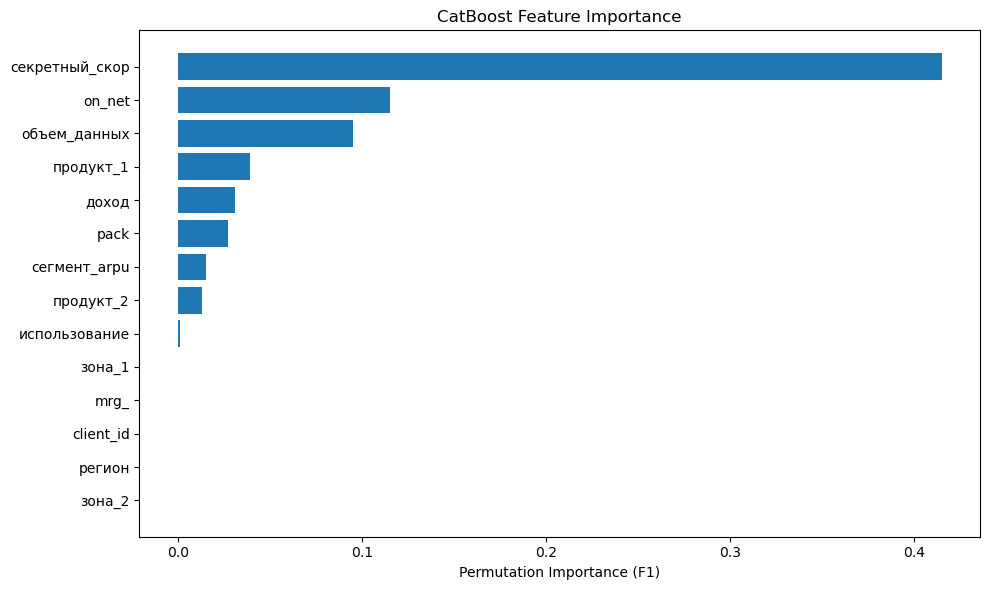

In [109]:
# permutation importance
result = permutation_importance(model, X_val, y_val, n_repeats=10, random_state=42, scoring='f1')

sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (F1)")
plt.title("CatBoost Feature Importance")
plt.tight_layout()
plt.show()


In [74]:
import joblib

# Сохраняем модель
model.save_model("catboost_model.cbm")


## код логики production функции ↓↓↓
У нас маленькая компания, поэтому есть ограничения на вычислительные ресурсы. __Ограничение на число CPU в модели внутри функции def get_score - 1 ядро, это означает что нужно ставить следующие параметры (модель должна работать на одном CPU)__
Если вы обучались на нескольких ядрах CPU (или даже GPU) - поменяйте параметры в уже обученной модели, чтобы в production она использовала только одно ядро

- это нужно явно показать в коде
- для уже обученных моделей:
- для catboost - model.predict(thread_count=1)
- для lightgbm - model.set_params(n_jobs=1) и затем model.get_params().get('n_jobs')
- для xgboost - model.set_params(n_jobs=1) и затем model.get_params()['n_jobs']
- для других классификаторов смотрите документацию



In [94]:
from catboost import CatBoostClassifier
import pandas as pd
import os

MODEL_PATH = "catboost_model.cbm"


model = CatBoostClassifier()
if os.path.exists(MODEL_PATH):
    model.load_model(MODEL_PATH)
else:
    raise FileNotFoundError("Model file not found. Please make sure catboost_model.cbm is available.")


numerical = [  'доход', 'сегмент_arpu',
             'объем_данных', 'on_net', 'продукт_1', 'продукт_2', 'зона_1', 'зона_2', 'секретный_скор']
categorical = ['использование', 'регион', 'pack']
boolean_features = ['mrg_']

def get_score(dict_input):
    client_id = dict_input["client_id"]

    df = pd.DataFrame([dict_input])

    df = df.drop(columns=['сумма', 'частота_пополнения', 'частота', 'pack_freq'])
    for col in numerical:
        if col not in df.columns or pd.isna(df.at[0, col]):
            median = df[col].median()
            df[col] = df[col].fillna(median)  
    for col in categorical:
        if col not in df.columns or pd.isna(df.at[0, col]):
            df[col] = 'unknown'


    binary_prediction = int(model.predict(df, thread_count=1)[0])

    return {
        "client_id": client_id,
        "prediction": binary_prediction,
    }


In [37]:
# подсказка

# следите за своей предобработкой
# основное время работы функции должна занимать модель
# можно использовать специальное расширение для понимания - сколько выполняется по времени каждая часть кода
# row_input = ...
# pip install line_profiler
# from line_profiler import profile
# %load_ext line_profiler
# %lprun -f get_score get_score(row_input)

______
## Тут нужно написать код для пятого пункта дз ↓↓↓

*проверка качества предсказания модели (без знания о целевой переменной, только на основе входных данных и выходного предсказания)*

In [38]:
# место для вашего кода

In [95]:
# используйте этот код для расчета качества вашей модели
# процесс должен быть итеративным - поэтмоу используется цикл
# не забудте сделать понятную визуализацию 

preds = []

for row in tqdm(test.itertuples(index=False), total=len(test)):

    dict_input_ = {
        "client_id": row.client_id,
        "регион": row.регион,
        "использование": row.использование,
        "сумма": row.сумма,
        "частота_пополнения": row.частота_пополнения,
        "доход": row.доход,
        "сегмент_arpu": row.сегмент_arpu,
        "частота": row.частота,
        "объем_данных": row.объем_данных,
        "on_net": row.on_net,
        "продукт_1": row.продукт_1,
        "продукт_2": row.продукт_2,
        "зона_1": row.зона_1,
        "зона_2": row.зона_2,
        "mrg_": row.mrg_,
        "секретный_скор": row.секретный_скор,
        "pack": row.pack,
        "pack_freq": row.pack_freq,
    }

    score_result = get_score(dict_input_)

    preds.append(score_result['prediction'])

    # Место для вашего кода для оценки качества модели
    # - pass

100%|██████████| 497586/497586 [06:34<00:00, 1262.81it/s]


In [40]:
# pass

## Место для вашего кода ↑↑↑
_______

## Автоматические проверки работы ↓↓↓
### Этот код менять нельзя, иначе проверки в ноутбуке могут сломаться

## тест 1: проверка input модели (1)

In [96]:
row_input = {
    'client_id': 1010348,
    'регион': 'Нептун',
    'использование': '>24LY',
    'сумма': 31.69021931132696,
    'частота_пополнения': 16.0,
    'доход': 42653.164535362455,
    'сегмент_arpu': 441.45,
    'частота': 4.242640687119285,
    'объем_данных': 32.01562118716424,
    'on_net': np.nan,
    'продукт_1': 12.0,
    'продукт_2': np.nan,
    'зона_1': np.nan,
    'зона_2': np.nan,
    'mrg_': False,
    'секретный_скор': 0.6065573770491803,
    'pack': 'трафик: 100 (условие) 40mb,_сутки',
    'pack_freq': 3.0,
    'binary_target': 0
}

In [97]:
# если завершилось без ошибок - тест пройден
get_score(row_input)

{'client_id': 1010348, 'prediction': 0}

## тест 2: проверка input модели (2)

In [98]:
row_input = {
    'client_id': -999,
    'регион': 'Калифорния',
    'использование': '<2года',
    'сумма': -999,
    'частота_пополнения': -16.0,
    'доход': -42653.164535362455,
    'сегмент_arpu': -441.45,
    'частота': 0.1,
    'объем_данных': -1,
    'on_net': np.nan,
    'продукт_1': -12.0,
    'продукт_2': np.nan,
    'зона_1': np.nan,
    'зона_2': np.nan,
    'mrg_': True,
    'секретный_скор': -0.6065573770491803,
    'pack': 'трафик Тройное условие 123',
    'pack_freq': -3.0,
    'binary_target': -0.1
}

In [99]:
# если завершилось без ошибок - тест пройден
get_score(row_input)

{'client_id': -999, 'prediction': 1}

## тест 3: проверка output модели

In [100]:
get_score_result = get_score(row_input)

In [101]:
# если завершилось без ошибок - тест пройден
assert get_score_result['prediction'] in [0, 1]

In [102]:
# если завершилось без ошибок - тест пройден
assert not bool(set(get_score_result.keys()) - set(['client_id', 'prediction']))

## тест 4: мониторинг времени (1)
- зеленый цвет названия графика означает - что тест пройден
- красный цвет названия графика означает - что тест не пройден

In [103]:
%%time

# тут ничего менять не нужно
times = []
preds = []

for row in tqdm(test.itertuples(index=False), total=len(test)):

    dict_input_ = {
        "client_id": row.client_id,
        "регион": row.регион,
        "использование": row.использование,
        "сумма": row.сумма,
        "частота_пополнения": row.частота_пополнения,
        "доход": row.доход,
        "сегмент_arpu": row.сегмент_arpu,
        "частота": row.частота,
        "объем_данных": row.объем_данных,
        "on_net": row.on_net,
        "продукт_1": row.продукт_1,
        "продукт_2": row.продукт_2,
        "зона_1": row.зона_1,
        "зона_2": row.зона_2,
        "mrg_": row.mrg_,
        "секретный_скор": row.секретный_скор,
        "pack": row.pack,
        "pack_freq": row.pack_freq,
    }

    # оценка времени работы функции скоринга
    stime = time.time()
    score_result = get_score(dict_input_)
    times.append((time.time() - stime))

    # сохранение предиктов для будущей оценки
    preds.append(score_result['prediction'])

times = np.array(times) * 1000

100%|██████████| 497586/497586 [06:37<00:00, 1250.63it/s]

CPU times: user 6min 33s, sys: 3.1 s, total: 6min 36s
Wall time: 6min 37s


#### Отрисовка оценки времени работы

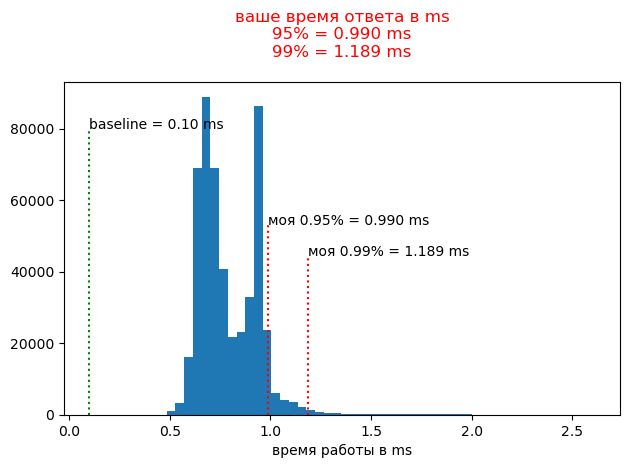

In [104]:
plt_vals = plt.hist(times, bins=np.linspace(np.quantile(times, 0.001), np.quantile(times, 0.999)))

plt.vlines(0.10, 0, plt_vals[0].max() * 0.9, color='green', linestyle=':')
plt.text(0.10, plt_vals[0].max() * 0.9, s='baseline = 0.10 ms', color='black', rotation=0)

plt.vlines(np.quantile(times, 0.95), 0, plt_vals[0].max() * 0.6, color='red', linestyle=':')
plt.vlines(np.quantile(times, 0.99), 0, plt_vals[0].max() * 0.5, color='red', linestyle=':')

plt.text(
    np.quantile(times, 0.95), plt_vals[0].max() * 0.6, 
    s=f'моя 0.95% = {np.quantile(times, 0.95):0.3f} ms', color='black', rotation=0
)
plt.text(
    np.quantile(times, 0.99), plt_vals[0].max() * 0.5, 
    s=f'моя 0.99% = {np.quantile(times, 0.99):0.3f} ms', color='black', rotation=0
)

plt.title(
    f'ваше время ответа в ms\n95% = {np.quantile(times, 0.95):0.3f} ms\n99% = {np.quantile(times, 0.99):0.3f} ms', 
    y=1.05, 
    color=(
        'green' 
        if (round(np.quantile(times, 0.95), 3) <= 0.10) & (round(np.quantile(times, 0.99), 3) <= 0.10) 
        else 'red'
    )
)

plt.xlabel('время работы в ms')
plt.tight_layout()
plt.show()

In [50]:
# Тут мы должны увидеть, что модель выдает предсказания быстрее ожидаемого
# Наше предсказание должно быть быстрее baseline в каждом случае

## тест 5: мониторинг времени (2)

In [105]:
row_input = {
    'client_id': -100,
    'регион': 'Plan_1',
    'использование': '<000',
    'сумма': 0,
    'частота_пополнения': 0.0,
    'доход': np.nan,
    'сегмент_arpu': np.nan,
    'частота': np.nan,
    'объем_данных': np.nan,
    'on_net': np.nan,
    'продукт_1': np.nan,
    'продукт_2': np.nan,
    'зона_1': np.nan,
    'зона_2': np.nan,
    'mrg_': True,
    'секретный_скор': 0.0,
    'pack': np.nan,
    'pack_freq': np.nan,
}

In [106]:
%%timeit
_ = get_score(row_input)

# Ожидаем скорость быстрее 110 µs (<110 µs)

975 μs ± 19.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## тест 6: мониторинг f1 score
- зеленый цвет названия графика означает, что тест пройден
- красный цвет названия графика означает, что тест не пройден

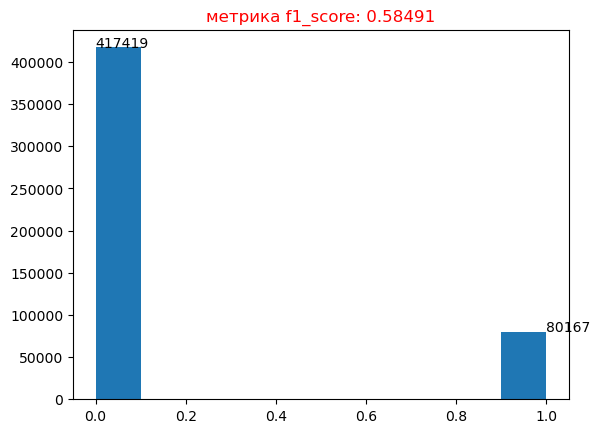

In [107]:
# Ожидаемая метрика >= 0.6450
plot_vals = plt.hist(preds)
plt.title(
    f"метрика f1_score: {f1_score(test['binary_target'], preds):0.5f}", 
    color=('red' if f1_score(test['binary_target'], preds) < 0.6450 else 'green')
)

plt.text(0, plot_vals[0][0], s=f"{plot_vals[0][0]:0.0f}")
plt.text(1, plot_vals[0][-1], s=f"{plot_vals[0][-1]:0.0f}")

plt.show()

## тест 7: Code Style
- воспользуемся библиотекой для оценки качества кода https://github.com/nbQA-dev/nbQA?tab=readme-ov-file#-examples 
- нужно установить актуальную версию pip install flake8
- нужно установить актуальную версию pip install -U nbqa
- в отдельной ячейке нужно выполнить команду: !nbqa flake8 ML_итоговая_шаблон.ipynb (см. эту команду ниже)
- поставьте вместо ML_итоговая_шаблон.ipynb ваше название ноутбука
- запрещается менять эту команду, за исключением названия ноутбука

In [108]:
os.system("nbqa flake8 --extend-ignore=W291,E501 teta_ML_итоговая_шаблон.ipynb & echo 'everything done'")

everything done


0

sh: nbqa: command not found


In [ ]:
# ячейка выше должна отпринтовать следующее
# everything done
# 0

# если помимо этого есть и другие строчки - это ошибки по pep8, их нужно исправлять
# например строчка teta_ML_итоговая_шаблон.ipynb:cell_27:1:1: F401 'scipy' imported but unused
# означает, что был бесполезный import scipy, который нигде не использовался

### Если все тесты пройдены успешно, вы можете претендовать на наивысшый балл (⌐■_■)

In [25]:
print('Ура!')

Ура!
